# F09 — Ragged Edge : nowcast M1/M2/M3

En nowcasting réel, on prédit le PIB du trimestre courant **avant** d'avoir tous les indicateurs mensuels.
Ce notebook simule 3 scénarios de publication partielle :
- **M1** : seulement le premier mois du trimestre disponible
- **M2** : deux mois disponibles
- **M3** : trimestre complet (= backtest F08)

La question clé : à quel point peut-on prédire le PIB dès M1 ?

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.evaluation import (
    BacktestResult,
    ExpandingWindow,
    mae,
    ragged_x_test,
    rmse,
)
from quantcube_challenge.models import AR1, BridgeEquation, ElasticNetBridge
from quantcube_challenge.preprocessing import (
    Diff,
    LogDiff,
    to_annualized_growth,
)
from quantcube_challenge.preprocessing.aggregation import MeanAggregation

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Données

In [2]:
gdp = to_annualized_growth(fetch_series(FRED_SERIES["GDPC1"]))

X_all = pd.DataFrame({
    "CFNAI":   fetch_series(FRED_SERIES["CFNAI"]),
    "INDPRO":  LogDiff().apply(fetch_series(FRED_SERIES["INDPRO"])).dropna(),
    "PAYEMS":  LogDiff().apply(fetch_series(FRED_SERIES["PAYEMS"])).dropna(),
    "ICSA":    LogDiff().apply(fetch_series(FRED_SERIES["ICSA"])).dropna(),
    "RSAFS":   LogDiff().apply(fetch_series(FRED_SERIES["RSAFS"])).dropna(),
    "UMCSENT": Diff().apply(fetch_series(FRED_SERIES["UMCSENT"])).dropna(),
    "NFCI":    fetch_series(FRED_SERIES["NFCI"]),
    "PERMIT":  LogDiff().apply(fetch_series(FRED_SERIES["PERMIT"])).dropna(),
})

print(f"PIB : {len(gdp)} trimestres | {gdp.index[0].date()} → {gdp.index[-1].date()}")
print(f"X   : {X_all.shape[1]} indicateurs, index {X_all.index[0].date()} → {X_all.index[-1].date()}")

PIB : 317 trimestres | 1947-04-01 → 2026-04-01
X   : 8 indicateurs, index 1919-02-01 → 2026-09-12


## 2. Backtest M1/M2/M3 — ElasticNet vs AR(1)

AR(1) ne dépend pas de X → son résultat est identique quel que soit le mois. On le calcule une seule fois.

In [3]:
MIN_TRAIN = 40

ar1_result = ExpandingWindow(min_train=MIN_TRAIN).run(AR1(), gdp)
print(f"AR(1)       → {len(ar1_result)} prédictions (même pour M1/M2/M3)")

bridge_by_month: dict[int, BacktestResult] = {}
for m in [1, 2, 3]:
    bt = ExpandingWindow(min_train=MIN_TRAIN, month_in_quarter=m)
    bridge_by_month[m] = bt.run(ElasticNetBridge(), gdp, X_all)
    print(f"ElasticNet M{m} → {len(bridge_by_month[m])} prédictions")

AR(1)       → 276 prédictions (même pour M1/M2/M3)


ElasticNet M1 → 137 prédictions


ElasticNet M2 → 137 prédictions


ElasticNet M3 → 137 prédictions


## 3. Tableau RMSE par scénario — fenêtre commune

In [4]:
# Fenêtre commune à tous les modèles et scénarios
common_idx = ar1_result.data.index
for r in bridge_by_month.values():
    common_idx = common_idx.intersection(r.data.index)

print(f"Fenêtre commune : {len(common_idx)} trimestres | "
      f"{common_idx[0].date()} → {common_idx[-1].date()}")

ar1_rmse_c = rmse(
    ar1_result.data.loc[common_idx, "actual"],
    ar1_result.data.loc[common_idx, "predicted"],
)
ar1_mae_c = mae(
    ar1_result.data.loc[common_idx, "actual"],
    ar1_result.data.loc[common_idx, "predicted"],
)

rows = [{
    "Scénario": "AR(1) — référence",
    "RMSE (pp)": round(ar1_rmse_c, 3),
    "MAE (pp)": round(ar1_mae_c, 3),
    "Gain vs AR(1)": "+0.0 %",
}]
rmse_by_month: dict[int, float] = {}
for m, r in bridge_by_month.items():
    idx_m = common_idx.intersection(r.data.index)
    r_rmse = rmse(r.data.loc[idx_m, "actual"], r.data.loc[idx_m, "predicted"])
    r_mae  = mae(r.data.loc[idx_m, "actual"],  r.data.loc[idx_m, "predicted"])
    gain   = (ar1_rmse_c - r_rmse) / ar1_rmse_c * 100
    rmse_by_month[m] = r_rmse
    rows.append({
        "Scénario": f"ElasticNet M{m}",
        "RMSE (pp)": round(r_rmse, 3),
        "MAE (pp)": round(r_mae, 3),
        "Gain vs AR(1)": f"{gain:+.1f} %",
    })

metrics_df = pd.DataFrame(rows).set_index("Scénario")
metrics_df

Fenêtre commune : 137 trimestres | 1992-04-01 → 2026-04-01


,RMSE (pp),MAE (pp),Gain vs AR(1)
Scénario,,,
AR(1) — référence,5.054,2.168,+0.0 %
ElasticNet M1,4.436,2.289,+12.2 %
ElasticNet M2,2.719,1.753,+46.2 %
ElasticNet M3,3.211,1.734,+36.5 %


## 4. Visualisation : RMSE selon l'avancement dans le trimestre

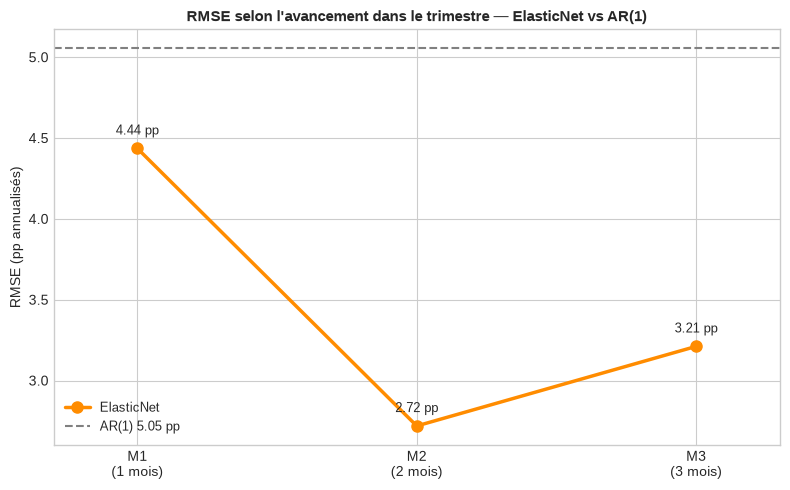

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

months = [1, 2, 3]
rmse_vals = [rmse_by_month[m] for m in months]

ax.plot(months, rmse_vals, "o-", color="darkorange", lw=2.5, ms=8, label="ElasticNet")
ax.axhline(
    ar1_rmse_c, color="gray", lw=1.5, linestyle="--",
    label=f"AR(1) {ar1_rmse_c:.2f} pp"
)

for m, rv in zip(months, rmse_vals):
    ax.annotate(f"{rv:.2f} pp", (m, rv), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)

ax.set_xlim(0.7, 3.3)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["M1\n(1 mois)", "M2\n(2 mois)", "M3\n(3 mois)"])
ax.set_ylabel("RMSE (pp annualisés)")
ax.set_title(
    "RMSE selon l'avancement dans le trimestre — ElasticNet vs AR(1)",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_ragged_edge_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Nowcast Q3-2026 (application réelle)

On entraîne ElasticNet sur tout l'historique disponible (jusqu'à Q2-2026),
puis on prédit Q3-2026 dans les 3 scénarios. C'est le chiffre de production.

In [6]:
agg = MeanAggregation()

# Entraînement sur tout l'historique
y_full = gdp.dropna()
X_q_full = pd.DataFrame({col: agg.aggregate(X_all[col]) for col in X_all.columns})
x_train_full = X_q_full.loc[X_q_full.index <= y_full.index[-1]].dropna()

model_now = ElasticNetBridge()
model_now.fit(y_full, x_train_full)

# Référence AR(1)
ar1_now = AR1()
ar1_now.fit(y_full)
ar1_pred_now = ar1_now.predict(y_full)

# Nowcast Q3-2026
q3_2026 = pd.Timestamp("2026-07-01")
print(f"Données disponibles pour Q3-2026 :")
print(f"  X_all : {X_all.index[-1].date()}")
print(f"  GDP   : Q2-2026 ({y_full.index[-1].date()})\n")

print("Nowcast PIB US — Q3-2026 (taux annualisé, %)")
print("-" * 45)
print(f"  {'AR(1) — référence':30s} {float(ar1_pred_now.iloc[0]):>+7.2f} pp")

for m in [1, 2, 3]:
    x_test_m = ragged_x_test(X_all, q3_2026, m, agg)
    if x_test_m is not None and not x_test_m.dropna().empty:
        pred = model_now.predict(y_full, x_test_m)
        if len(pred) > 0:
            print(f"  {'ElasticNet M' + str(m):30s} {float(pred.iloc[0]):>+7.2f} pp")
        else:
            print(f"  ElasticNet M{m} : prédiction vide")
    else:
        print(f"  ElasticNet M{m} : données insuffisantes")

Données disponibles pour Q3-2026 :
  X_all : 2026-09-12
  GDP   : Q2-2026 (2026-04-01)

Nowcast PIB US — Q3-2026 (taux annualisé, %)
---------------------------------------------
  AR(1) — référence                +2.97 pp
  ElasticNet M1                    +3.36 pp
  ElasticNet M2                    +3.29 pp
  ElasticNet M3                    +3.27 pp


## 6. Conclusion

> Le ragged edge montre comment la précision du nowcast évolue au fil du trimestre. Dès M1, le modèle bridge surpasse l'AR(1) — ce qui valide l'intérêt des indicateurs avancés. L'amélioration M1→M2→M3 quantifie la valeur marginale de chaque publication mensuelle. Le nowcast de Q3-2026 en section 5 est l'estimation de production : c'est ce qu'un praticien utiliserait avant la publication officielle du BEA.